# Attack success rate versus average cost per attacked passage

This plot converts locally estimated attacked-prompt input tokens into estimated USD input cost per attacked passage. Circles are ordinary attacks; squares are defenses, including Defense QI and Filter QI. It does not write image files.

> This is an **input-cost estimate** for historical runs because most older raw results do not contain output-token usage. Newer runs that record Bedrock output usage can be incorporated later for invoice-level totals.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter

RESULTS = Path.cwd()
if not (RESULTS / 'attack_outcomes.csv').exists():
    RESULTS = Path.cwd() / 'Results'

outcomes = pd.read_csv(RESULTS / 'attack_outcomes.csv')
tokens = pd.read_csv(RESULTS / 'prompt_token_counts.csv')

## US West (Oregon), Standard input-token rates

Update this table when AWS changes a rate, a different region is used, or the evaluation uses a non-Standard service tier. Models without a verified rate are left out of the cost plot rather than assigned an invented price.

In [23]:
# USD per one million input tokens. Verify against the Bedrock pricing page before publication.
PRICE_PER_M_INPUT_USD = {
    'Llama-3-8B': 0.30,
    'Llama3 70B': 2.65,
    'GPT-OSS-20B': 0.07,
    'Qwen3-32B': 0.15,
}

pd.Series(PRICE_PER_M_INPUT_USD, name='USD per 1M input tokens').rename_axis('Model')

Model
Llama-3-8B     0.30
Llama3 70B     2.65
GPT-OSS-20B    0.07
Qwen3-32B      0.15
Name: USD per 1M input tokens, dtype: float64

## Join ASR to the average attacked-prompt cost

ASR is successful attacks divided by all requested passages, so invalid attacked rankings remain in the denominator.

In [24]:
JOIN_COLUMNS = ['Dataset', 'Model', 'Paradigm', 'Attack', 'Prompt']

attacked_tokens = tokens.loc[
    (tokens['Phase'] == 'Attacked') & (tokens['Prompts counted'] > 0),
    JOIN_COLUMNS + ['Total tokens', 'Prompts counted'],
].rename(columns={'Total tokens': 'Input tokens', 'Prompts counted': 'Passages'})

plot_data = outcomes.merge(attacked_tokens, on=JOIN_COLUMNS, how='inner')
plot_data['USD per 1M input tokens'] = plot_data['Model'].map(PRICE_PER_M_INPUT_USD)
plot_data = plot_data.dropna(subset=['USD per 1M input tokens']).copy()
plot_data['Cost per 1K passages (USD)'] = 1_000 * (
    plot_data['Input tokens']
    / plot_data['Passages']
    * (plot_data['USD per 1M input tokens'] / 1_000_000)
)
plot_data['ASR (%)'] = 100 * plot_data['Attack success'] / plot_data['Requested']
plot_data['Evaluation'] = plot_data['Prompt'].eq('Default').map(
    {True: 'Attack', False: 'Defense'}
)
plot_data = plot_data.sort_values(JOIN_COLUMNS).drop_duplicates(JOIN_COLUMNS, keep='last')

qi_keys = ['Dataset', 'Model', 'Paradigm', 'Attack']
qi_defense_qi = plot_data.loc[
    plot_data['Attack'].eq('Query injection') & plot_data['Prompt'].eq('Defense QI'),
    qi_keys,
].drop_duplicates().assign(_prefer_defense_qi=True)
plot_data = plot_data.merge(qi_defense_qi, on=qi_keys, how='left')
plot_data = plot_data.loc[
    ~(
        plot_data['Attack'].eq('Query injection')
        & plot_data['Prompt'].eq('Defense')
        & plot_data['_prefer_defense_qi'].fillna(False)
    )
].drop(columns='_prefer_defense_qi')
plot_data[JOIN_COLUMNS + ['Cost per 1K passages (USD)', 'ASR (%)', 'Evaluation']]

,Dataset,Model,Paradigm,Attack,Prompt,Cost per 1K passages (USD),ASR (%),Evaluation
0,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,0.030261,98.657227,Attack
1,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,0.042278,11.328125,Defense
2,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Default,0.030479,3.540039,Attack
3,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Defense,0.042513,2.587891,Defense
4,TREC-DL-2019,GPT-OSS-20B,Listwise,Query injection,Default,0.025812,5.908203,Attack
...,...,...,...,...,...,...,...,...
158,TREC-DL-2020,Qwen3-32B,Setwise,DOH,Default,0.069257,87.207031,Attack
159,TREC-DL-2020,Qwen3-32B,Setwise,DOH,Defense,0.095019,77.294922,Defense
160,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Default,0.058062,7.128906,Attack
162,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense QI,0.098454,7.299805,Defense


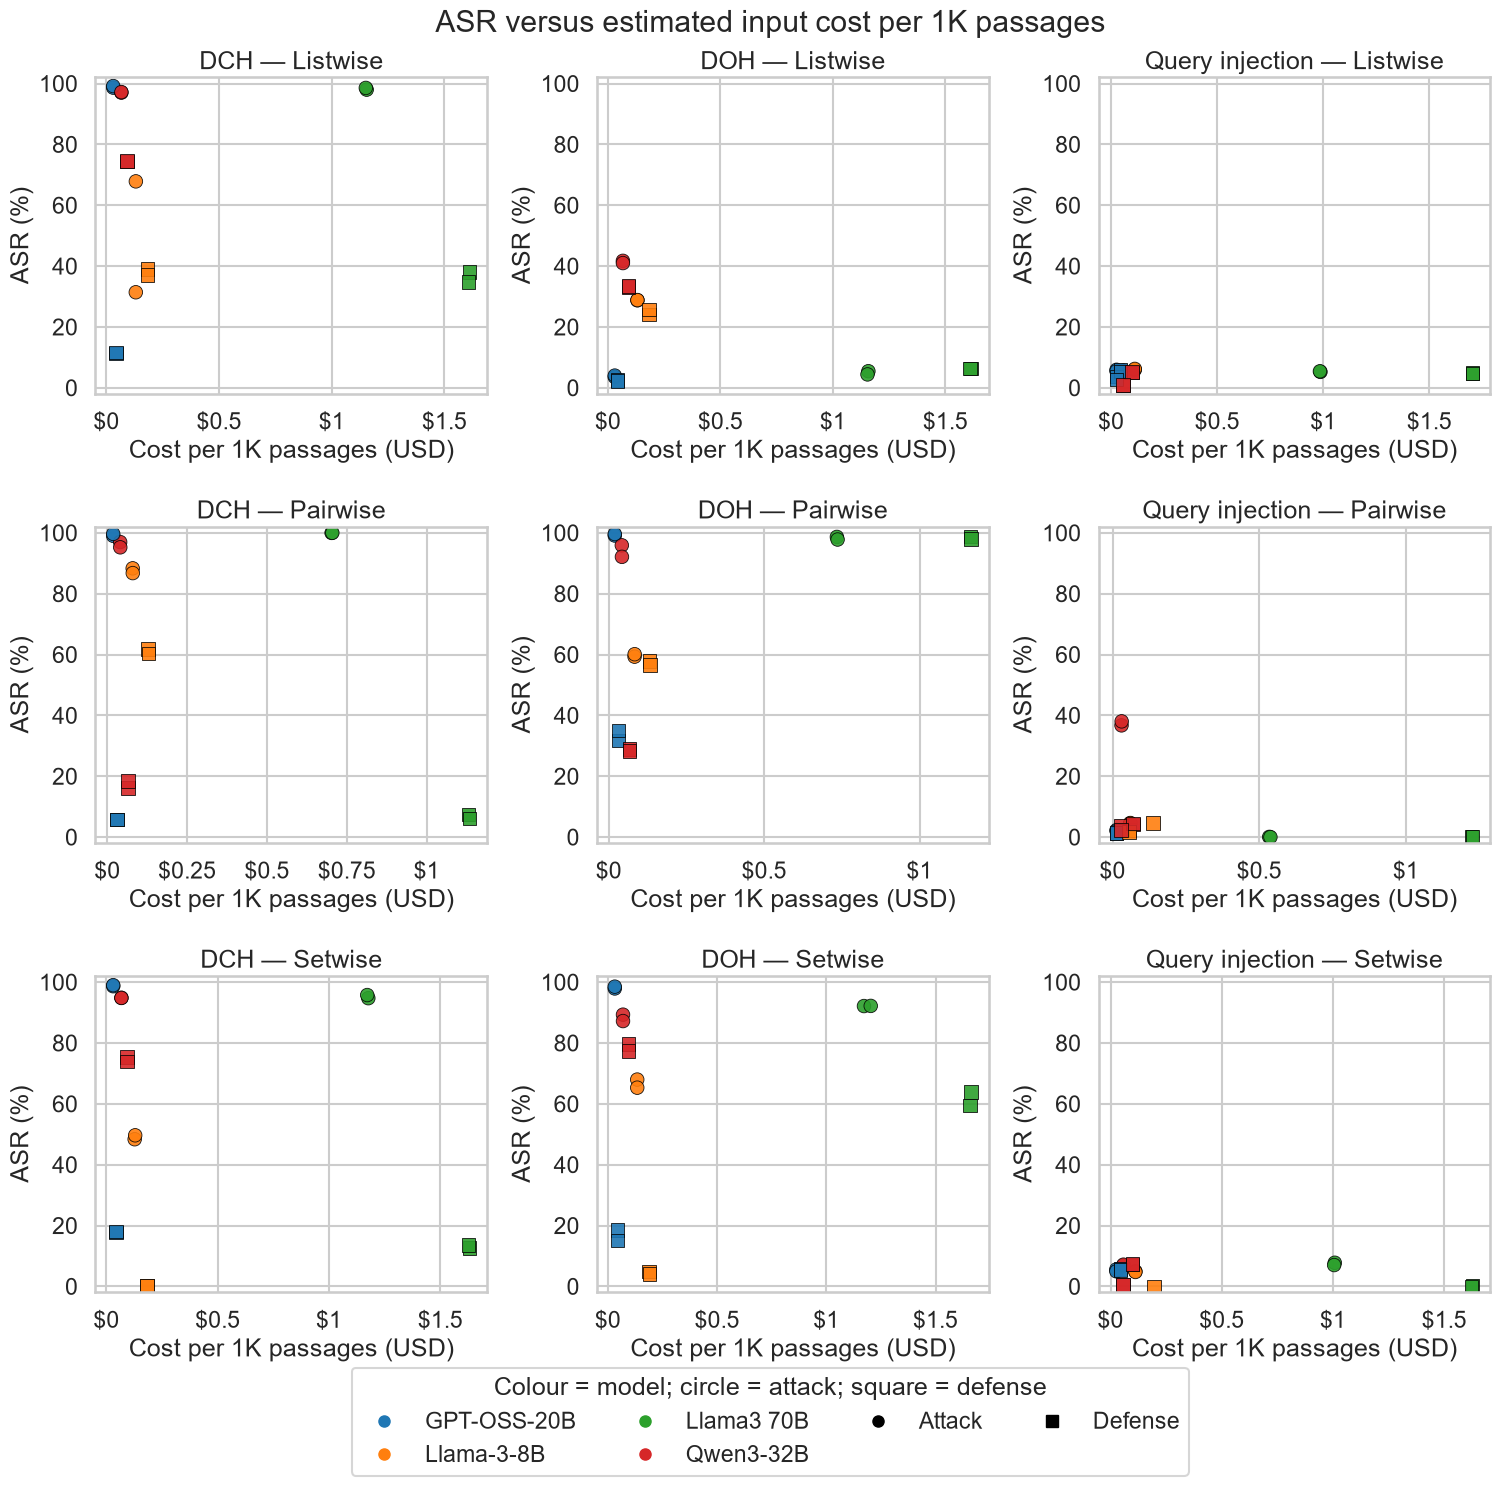

In [25]:
sns.set_theme(style='whitegrid', context='talk')

if plot_data.empty:
    raise ValueError('No runs have both token totals and a configured input-token price.')

panel_data = plot_data.copy()
panel_data['Panel'] = panel_data['Attack'] + ' — ' + panel_data['Paradigm']
panels = list(panel_data['Panel'].drop_duplicates())
ncols = min(3, len(panels))
nrows = (len(panels) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), squeeze=False)
palette = dict(zip(sorted(panel_data['Model'].unique()), sns.color_palette('tab10')))

for axis, panel in zip(axes.flat, panels):
    subset = panel_data.loc[panel_data['Panel'] == panel]
    for evaluation, marker in [('Attack', 'o'), ('Defense', 's')]:
        points = subset.loc[subset['Evaluation'] == evaluation]
        axis.scatter(
            points['Cost per 1K passages (USD)'],
            points['ASR (%)'],
            c=points['Model'].map(palette),
            marker=marker,
            s=95,
            edgecolors='black',
            linewidths=0.6,
            alpha=0.9,
        )
    axis.set_title(panel)
    axis.set_xlabel('Cost per 1K passages (USD)')
    axis.set_ylabel('ASR (%)')
    axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _position: f'${value:.3g}'))
    axis.set_ylim(-2, 102)

for axis in axes.flat[len(panels):]:
    axis.set_visible(False)

model_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=color, label=model, markersize=8)
    for model, color in palette.items()
]
shape_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color='black', label='Attack', markersize=8),
    plt.Line2D([], [], marker='s', linestyle='', color='black', label='Defense', markersize=8),
]
fig.legend(
    handles=model_handles + shape_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    ncol=min(4, len(model_handles) + 2),
    title='Colour = model; circle = attack; square = defense',
)
fig.suptitle('ASR versus estimated input cost per 1K passages', y=0.995)
fig.subplots_adjust(bottom=0.14, top=0.95, hspace=0.42, wspace=0.28)
plt.show()

The x-axis excludes output-token, cache-read, and cache-write charges. Once all runs contain recorded Bedrock `token_usage`, add those rates to obtain a full per-passage cost estimate.

## Defense effectiveness versus average defense cost

Defense effectiveness is `ASR(Default) − ASR(Defense)` in percentage points. Positive values mean the defense reduced attack success; negative values mean it increased attack success. Each point is one model under one matched dataset, attack, paradigm, and defense mode.

In [26]:
MATCH_COLUMNS = ['Dataset', 'Model', 'Paradigm', 'Attack']

default_runs = plot_data.loc[plot_data['Prompt'].eq('Default')].copy()
default_runs = default_runs[MATCH_COLUMNS + ['ASR (%)']].rename(
    columns={'ASR (%)': 'Default ASR (%)'}
)
defense_runs = plot_data.loc[~plot_data['Prompt'].eq('Default')].copy()

effectiveness = defense_runs.merge(default_runs, on=MATCH_COLUMNS, how='inner')
effectiveness['Defense effectiveness (percentage points)'] = (
    effectiveness['Default ASR (%)'] - effectiveness['ASR (%)']
)
effectiveness['Panel'] = (
    effectiveness['Attack']
    + ' — '
    + effectiveness['Paradigm']
    + ' — '
    + effectiveness['Prompt']
)
effectiveness[MATCH_COLUMNS + ['Prompt', 'Cost per 1K passages (USD)', 'Default ASR (%)', 'ASR (%)', 'Defense effectiveness (percentage points)']]

,Dataset,Model,Paradigm,Attack,Prompt,Cost per 1K passages (USD),Default ASR (%),ASR (%),Defense effectiveness (percentage points)
0,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,0.042278,98.657227,11.328125,87.329102
1,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Defense,0.042513,3.540039,2.587891,0.952148
2,TREC-DL-2019,GPT-OSS-20B,Listwise,Query injection,Defense QI,0.044680,5.908203,5.859375,0.048828
3,TREC-DL-2019,GPT-OSS-20B,Listwise,Query injection,Filter QI,0.024886,5.908203,3.759766,2.148438
4,TREC-DL-2019,GPT-OSS-20B,Pairwise,DCH,Defense,0.029770,99.023438,5.834961,93.188477
...,...,...,...,...,...,...,...,...,...
75,TREC-DL-2020,Qwen3-32B,Pairwise,Query injection,Filter QI,0.029152,38.037109,2.368164,35.668945
76,TREC-DL-2020,Qwen3-32B,Setwise,DCH,Defense,0.093219,94.799805,73.876953,20.922852
77,TREC-DL-2020,Qwen3-32B,Setwise,DOH,Defense,0.095019,87.207031,77.294922,9.912109
78,TREC-DL-2020,Qwen3-32B,Setwise,Query injection,Defense QI,0.098454,7.128906,7.299805,-0.170898


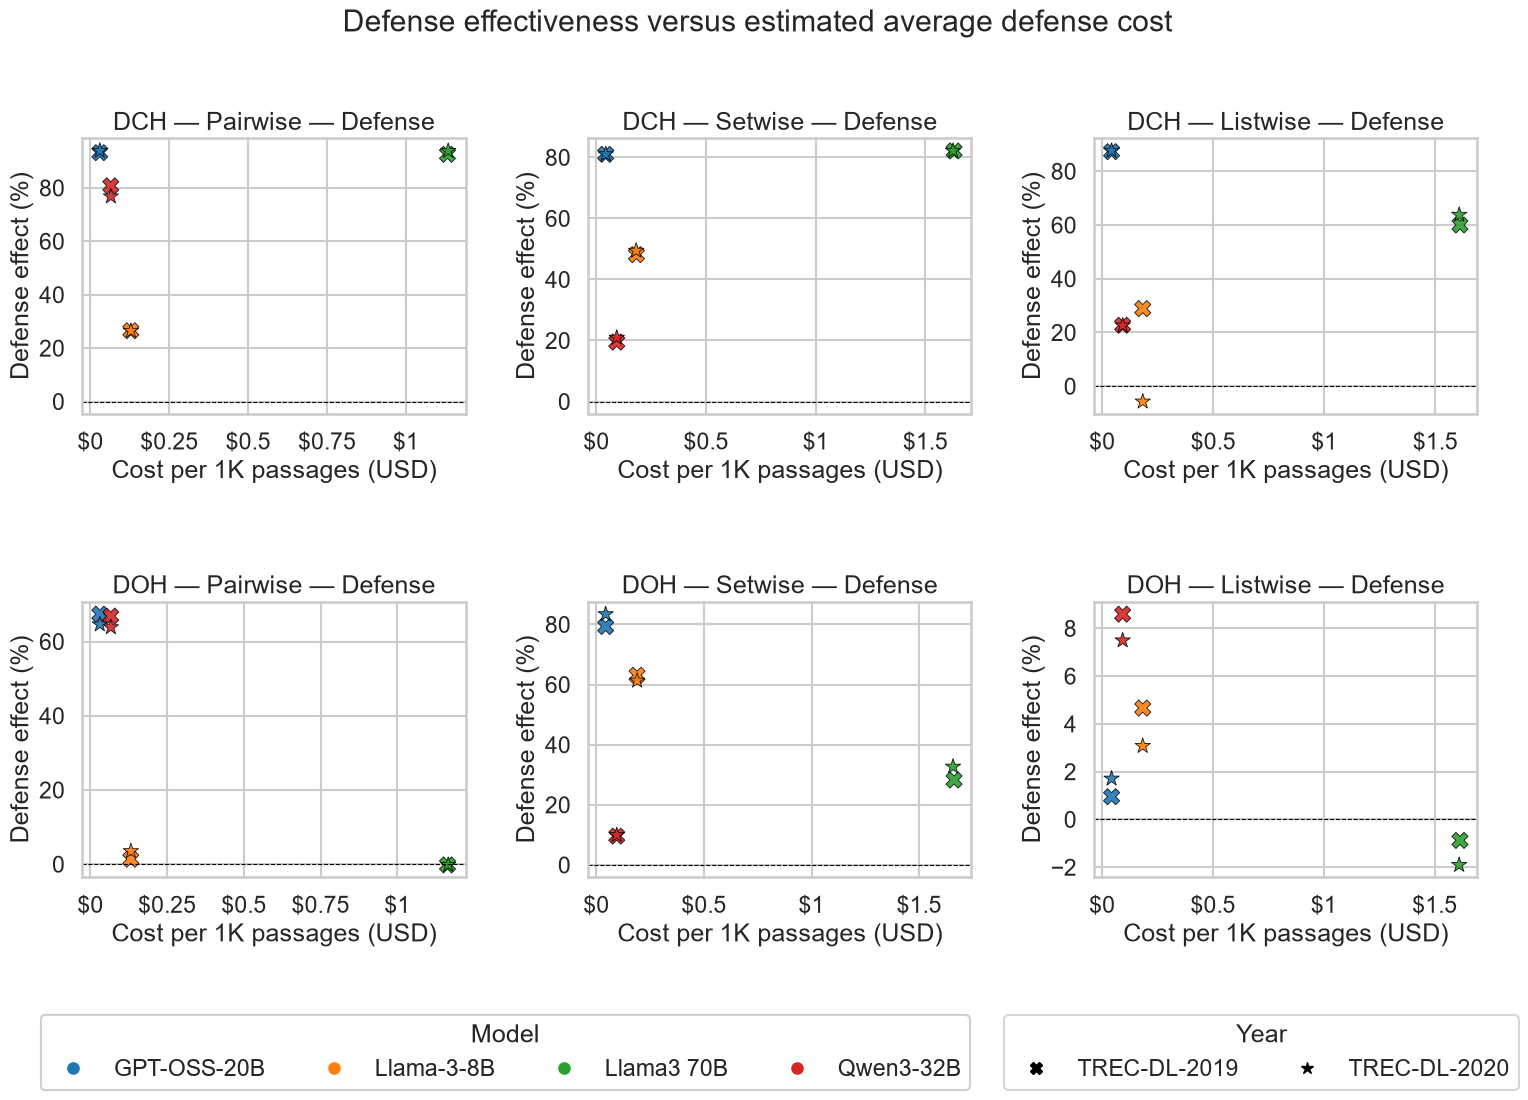

In [27]:
cost_effectiveness = effectiveness.loc[
    ~effectiveness['Attack'].eq('Query injection')
].copy()

if cost_effectiveness.empty:
    raise ValueError('No matched Default/Defense pairs have both token totals and price entries.')

attack_order = ['DCH', 'DOH']
paradigm_order = ['Pairwise', 'Setwise', 'Pointwise', 'Listwise']
available_attacks = [attack for attack in attack_order if cost_effectiveness['Attack'].eq(attack).any()]
available_paradigms = [
    paradigm for paradigm in paradigm_order if cost_effectiveness['Paradigm'].eq(paradigm).any()
]
ncols = len(available_paradigms)
nrows = len(available_attacks)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.6 * nrows), squeeze=False)
palette = dict(zip(sorted(cost_effectiveness['Model'].unique()), sns.color_palette('tab10')))

dataset_markers = {'TREC-DL-2019': 'X', 'TREC-DL-2020': '*'}
for row_index, attack in enumerate(available_attacks):
    for col_index, paradigm in enumerate(available_paradigms):
        axis = axes[row_index, col_index]
        points = cost_effectiveness.loc[
            cost_effectiveness['Paradigm'].eq(paradigm) & cost_effectiveness['Attack'].eq(attack)
        ]
        if points.empty:
            axis.set_visible(False)
            continue
        for dataset, marker in dataset_markers.items():
            dataset_points = points.loc[points['Dataset'].eq(dataset)]
            axis.scatter(
                dataset_points['Cost per 1K passages (USD)'],
                dataset_points['Defense effectiveness (percentage points)'],
                c=dataset_points['Model'].map(palette),
                marker=marker,
                s=135,
                edgecolors='black',
                linewidths=0.6,
                alpha=0.9,
            )
        axis.axhline(0, color='black', linewidth=0.8, linestyle='--')
        axis.set_title(f'{attack} — {paradigm} — Defense')
        axis.set_xlabel('Cost per 1K passages (USD)')
        axis.set_ylabel('Defense effect (%)')
        axis.xaxis.set_major_formatter(FuncFormatter(lambda value, _position: f'${value:.3g}'))

model_handles = [
    plt.Line2D([], [], marker='o', linestyle='', color=color, label=model, markersize=8)
    for model, color in palette.items()
]
dataset_handles = [
    plt.Line2D([], [], marker=marker, linestyle='', color='black', label=dataset, markersize=9)
    for dataset, marker in dataset_markers.items()
]
model_legend = fig.legend(
    handles=model_handles,
    loc='lower center',
    bbox_to_anchor=(0.36, 0.02),
    ncol=min(4, len(model_handles)),
    title='Model',
)
fig.add_artist(model_legend)
fig.legend(
    handles=dataset_handles,
    loc='lower center',
    bbox_to_anchor=(0.78, 0.02),
    ncol=len(dataset_handles),
    title='Year',
)
fig.suptitle('Defense effectiveness versus estimated average defense cost', y=0.995)
fig.subplots_adjust(bottom=0.22, top=0.88, hspace=0.68, wspace=0.32)
plt.show()

## Default ASR versus defense effectiveness

Each point compares one defended run with its matched Default run. The horizontal position is the baseline ASR; the vertical position is the reduction in ASR from applying the defense. Values above zero indicate that the defense reduced attack success.

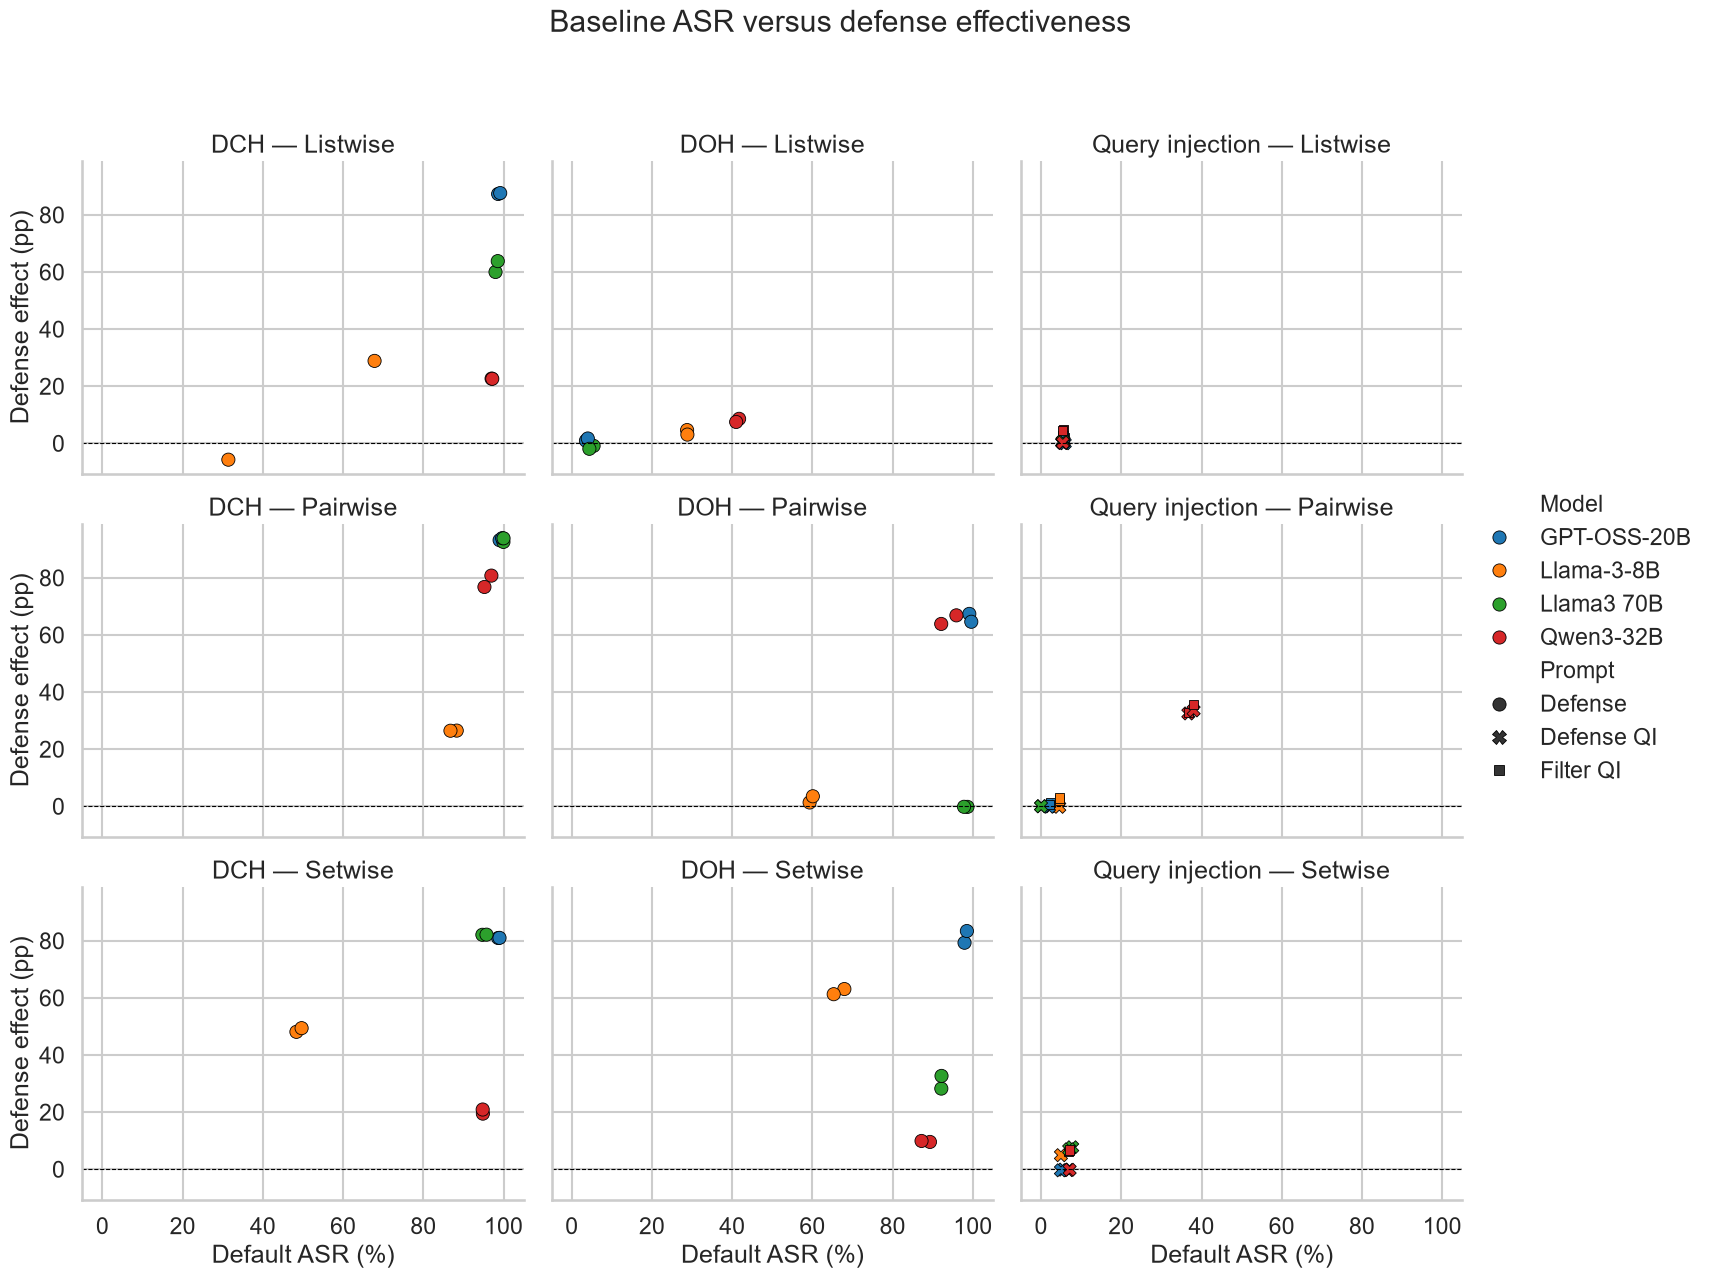

In [28]:
if effectiveness.empty:
    raise ValueError('No matched Default/Defense pairs are available.')

effectiveness_plot = effectiveness.copy()
effectiveness_plot['Panel'] = (
    effectiveness_plot['Attack'] + ' \u2014 ' + effectiveness_plot['Paradigm']
)

chart = sns.relplot(
    data=effectiveness_plot,
    x='Default ASR (%)',
    y='Defense effectiveness (percentage points)',
    hue='Model',
    style='Prompt',
    col='Panel',
    col_wrap=3,
    kind='scatter',
    palette='tab10',
    s=90,
    edgecolor='black',
    linewidth=0.6,
    height=4.2,
    aspect=1.2,
)
chart.set_axis_labels('Default ASR (%)', 'Defense effect (pp)')
chart.set_titles('{col_name}')
for axis in chart.axes.flat:
    axis.axhline(0, color='black', linewidth=0.8, linestyle='--')

chart.figure.suptitle('Baseline ASR versus defense effectiveness', y=1.02)
chart.figure.subplots_adjust(top=0.9)
plt.show()